# CRC Multiplex Tissue Imaging — Cell Clustering with HFcluster

**Purpose of this notebook:** This is a work in progress represents a learning project which aims to reproduce some of the results in the paper: "Coordinated Cellular Neighborhoods Orchestrate Antitumoral Immunity at the Colorectal Cancer Invasive Fron" by Christian M. Schürch et al.
Here we load single-cell, multi-marker intensity tables exported from a
CODEX/PhenoCycler run on colorectal cancer (CRC) tissue, clean up autofluorescent/low-quality
cells, and cluster cells into phenotypes using
[`HFcluster`](https://github.com/will-yx/HFcluster).

**What is `HFcluster`?** It is a semi-supervised, two-step clustering strategy built for noisy
multiplex-imaging data (as opposed to droplet scRNA-seq, where signal-to-noise is far more
uniform):

1. **High-confidence subset + Louvain clustering.** For each marker, cells are ranked and an
   "elbow" is found in the sorted, normalized intensity distribution to call cells as confidently
   positive or negative for that marker (`find_highconf_normalized`). Only cells with an
   unambiguous marker profile go into this step. These "high-confidence" cells are then clustered
   with the Louvain community-detection algorithm on a shared-nearest-neighbor graph (via
   `scluster`), which also produces a 2D UMAP embedding for visualization.
2. **Label propagation.** The remaining cells (those that were too ambiguous/dim to be trusted in
   step 1) are assigned to the nearest high-confidence cluster in expression space
   (`propagateLabels`). This lets every cell in the dataset receive a final `clusterID`, not just
   the "easy" ones.

The rationale: Louvain clustering directly on *all* cells (including noisy/dim ones) tends to
produce unstable, hard-to-interpret clusters in imaging data. Anchoring the cluster definitions on
high-confidence cells first, then propagating, gives more reproducible phenotype calls.

**Notebook structure:**
1. Setup (imports, paths)
2. Load raw data + QC filtering (autofluorescence / DNA content)
3. Normalize marker intensities across runs
4. Attach sample metadata (tissue ID, condition/group)
5. Select markers and run HFcluster (high-confidence Louvain + UMAP + label propagation)
6. Visualize & interpret cluster phenotypes (heatmap, cluster sizes)
7. Save annotated output
8. **Guide: how to interpret the results**

> **Note:** This notebook expects the `HFcluster` package (and its dependencies `Split.py`,
> `CellNeighborhood.py`) to be on your Python path, and expects input files in the Akoya/CRISP
> CODEX processor `.tsv`/`.csv` export format (one file per tissue region, cells as rows, markers
> as columns).


## 1. Setup

Import the `HFcluster` package and its companion modules, plus standard scientific-Python
libraries. `HFcluster` is not installed as a normal pip package here — instead its folder is added
to `sys.path` — so **update the path below to match where you cloned/downloaded the `HFcluster`
repository on your machine.**


In [5]:
# --- Standard library ---
import os
import sys
import glob
import csv
import re
import time
import importlib

# --- Scientific Python stack ---
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set(font_scale=1)
sns.set_style("white")

# --- HFcluster package -------------------------------------------------
# EDIT ME: path to the local clone of https://github.com/will-yx/HFcluster
HFCLUSTER_DIR = r"C:\Users\assem\Desktop\AI engineer\cancer markers\HFcluster-main"
sys.path.append(HFCLUSTER_DIR)

import HFcluster          # core loading / QC / clustering functions
import Split               # (HFcluster dependency) splits multi-tissue exports into regions
import CellNeighborhood    # spatial cellular-neighborhood analysis (used later, post-clustering)

# Custom XKCD-based color palette used later for plotting cluster colors
xkcd_cols = pd.read_csv(os.path.join(HFCLUSTER_DIR, "xkcd_hexcol.csv")).columns.values


## 2. Load data

### 2.1 Configure input/output locations

`HFcluster.loadData` expects one folder per CODEX **run**, each containing region-level
`.csv`/`.tsv` files (by default under a `tsv`/`processed/.../compensated` subfolder). Multiple
runs can be loaded together and will be concatenated, which is useful when a cohort was imaged
across several CODEX runs and needs run-level intensity normalization (see Section 3).


In [6]:
\
# EDIT ME: parent folder that contains one subfolder per CODEX run.
# NOTE: HFcluster builds paths as `path + run + subdir` with no separator inserted,
# so this MUST end in a trailing backslash (a plain string with an escaped "\\",
# not a raw string -- raw strings can't end in a single backslash).
path = "C:\\Users\\assem\\Desktop\\AI engineer\\cancer markers\\"

# EDIT ME: which run folders (under `path`) to load, e.g. ['run_AB'] or ['run1', 'run2', ...]
runs = ['run_AB']

# Subfolder (inside each run folder) where the per-region tsv/csv files live.
# Default matches the Akoya/CRISP CODEX processor output layout; set to "" if
# files sit directly inside the run folder.
subdir = 'tsv'

# Wildcard pattern used to find region files within `subdir`
filename_pattern = '*reg*.tsv'

# EDIT ME: where results/figures for this analysis will be written.
# Must NOT be the same folder as `path` (HFcluster will refuse to overwrite inputs).
outdir = "C:\\Users\\assem\\Desktop\\AI engineer\\cancer markers\\Results\\"
HFcluster.newDir(outdir)   # creates outdir if it doesn't already exist


### 2.2 Load regions and remove low-quality / autofluorescent cells

`HFcluster.loadData` reads every matching region file, tags each cell with its run/region of
origin, and (optionally) removes likely-autofluorescent or non-nucleated segmentation artifacts
based on DNA staining intensity:

- `DNAChannel` — the Hoechst channel from cycle 1, used as the primary "is this a real, intact
  nucleus" signal.
- `ManualDNAthreshold` — cells with Hoechst intensity below this value are dropped as
  under-segmented/empty objects (tune this using the biaxial plot in Section 2.3).
- `DRAQ5Channel` — an independent, late-cycle nuclear stain. Comparing Hoechst vs. DRAQ5
  (Section 2.3) helps identify autofluorescent debris (bright in one channel but not the other)
  that should be excluded from downstream clustering.
- `RemoveHighBlankCells=True` — also drops cells with abnormally high signal in the empty/"blank"
  acquisition channels, which usually indicates debris, folds, or imaging artifacts rather than
  real antibody staining.

`data` is returned as a **list of per-region DataFrames** (one per tissue region — needed later
for per-run rescaling), while `data_all` is the same cells already **concatenated into one
DataFrame** for convenience.


In [7]:
importlib.reload(HFcluster)

# Column names holding cell centroid coordinates in the input files
X = 'x:x'
Y = 'y:y'
Z = 'z:z'

# --- QC / filtering parameters ---
DNAChannel = 'Cyc_1_ch_1 (HOECHST1)'      # cycle-1 Hoechst = primary nuclear stain
ManualDNAthreshold = 750                  # cells dimmer than this are dropped (see 2.3 to tune)
DRAQ5Channel = 'Cyc_23_ch_4 (DRAQ5)'      # late-cycle independent nuclear stain

data, data_all = HFcluster.loadData(
    runs, path, subdir, filename_pattern,
    DNAChannel,
    Z=Z,
    RemoveHighBlankCells=True,
    DNAfilter=True,
    ManualDNAthreshold=ManualDNAthreshold,
    DRAQ5Channel=DRAQ5Channel,
)
# data      -> list of per-region DataFrames (pre-normalization), used in Section 3
# data_all  -> all regions concatenated into a single DataFrame, used for QC plotting below


Loading run_AB
['reg001_A.tsv', 'reg001_B.tsv', 'reg002_A.tsv', 'reg002_B.tsv', 'reg003_A.tsv', 'reg003_B.tsv', 'reg004_A.tsv', 'reg004_B.tsv', 'reg005_A.tsv', 'reg005_B.tsv', 'reg006_A.tsv', 'reg006_B.tsv', 'reg007_A.tsv', 'reg007_B.tsv', 'reg008_A.tsv', 'reg008_B.tsv', 'reg009_A.tsv', 'reg009_B.tsv', 'reg010_A.tsv', 'reg010_B.tsv', 'reg011_A.tsv', 'reg011_B.tsv', 'reg012_A.tsv', 'reg012_B.tsv', 'reg013_A.tsv', 'reg013_B.tsv', 'reg014_A.tsv', 'reg014_B.tsv', 'reg015_A.tsv', 'reg015_B.tsv', 'reg016_A.tsv', 'reg016_B.tsv', 'reg017_A.tsv', 'reg017_B.tsv', 'reg018_A.tsv', 'reg018_B.tsv', 'reg019_A.tsv', 'reg019_B.tsv', 'reg020_A.tsv', 'reg020_B.tsv', 'reg021_A.tsv', 'reg021_B.tsv', 'reg022_A.tsv', 'reg022_B.tsv', 'reg023_A.tsv', 'reg023_B.tsv', 'reg024_A.tsv', 'reg024_B.tsv', 'reg025_A.tsv', 'reg025_B.tsv', 'reg026_A.tsv', 'reg026_B.tsv', 'reg027_A.tsv', 'reg027_B.tsv', 'reg028_A.tsv', 'reg028_B.tsv', 'reg029_A.tsv', 'reg029_B.tsv', 'reg030_A.tsv', 'reg030_B.tsv', 'reg031_A.tsv', 'reg031_

### 2.3 QC plot: Hoechst vs. DRAQ5

Real, intact nuclei should be positive for **both** Hoechst and DRAQ5. Cells that are bright in
one channel but not the other are usually autofluorescent debris, segmentation artifacts, or
tissue folds rather than genuine cells.

**How to use this plot:** if the bulk of points does not separate cleanly from a low-intensity
"cloud" near the origin, or if `ManualDNAthreshold` above visibly cuts through the main cell
population instead of sitting in the gap below it, go back to Section 2.2 and adjust
`ManualDNAthreshold`, then re-run.


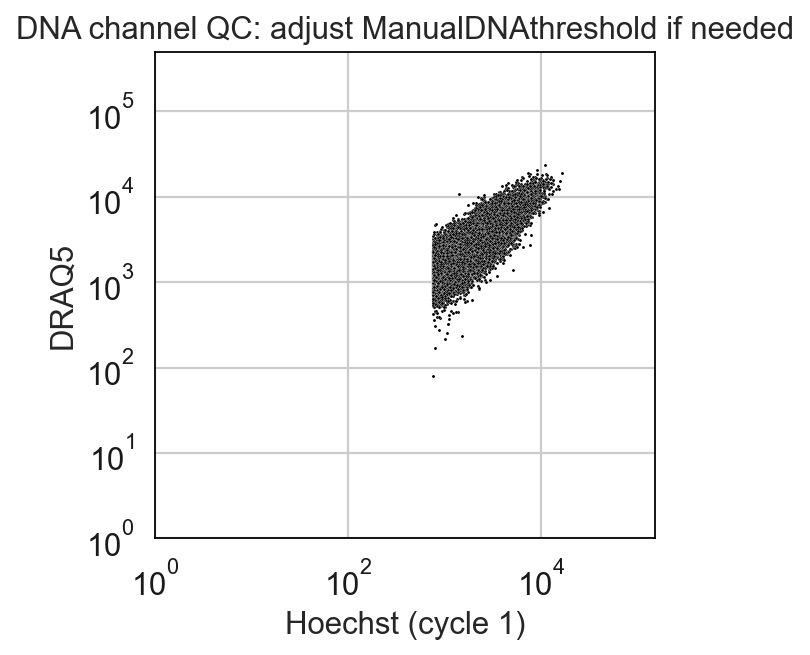

In [8]:
n_plot = min(50_000, len(data_all))
ax = sns.scatterplot(
    data=data_all.sample(n=n_plot, axis=0),
    x=DNAChannel, y=DRAQ5Channel,
    alpha=1, s=2, color='0',
)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1, 150000)
ax.set_ylim(1, 500000)
ax.set_xlabel('Hoechst (cycle 1)')
ax.set_ylabel('DRAQ5')
ax.set_title('DNA channel QC: adjust ManualDNAthreshold if needed')
plt.show()


## 3. Standardize marker intensities across runs

Raw intensities are not directly comparable across CODEX runs (or even across regions within a
run) due to differences in staining, exposure, and imaging conditions. `HFcluster.rescale` is
applied **per region** (hence the list comprehension over `data`, not `data_all`) to normalize
each marker's intensity distribution before clustering. Any residual negative values after
rescaling (an artifact of the normalization) are clipped to zero, since negative expression is not
biologically meaningful.


In [9]:
data_scaled = [HFcluster.rescale(region) for region in data]

data_all_scaled = pd.concat(data_scaled)
data_all_scaled.index = data_all.index          # restore the original (RunID, RegionID, ...) index
data_all_scaled[data_all_scaled < 0] = 0         # clip small negative values from rescaling


## 4. Attach sample metadata

### 4.1 Unique tissue IDs

Each physical tissue section is uniquely identified by the combination of its CODEX **run** and
**region** number (a single run can image many regions/cores, e.g. TMA spots). We build a
`tissueID` column so downstream per-tissue summaries (cluster composition, cell counts, etc.) are
unambiguous even across multiple runs.


In [10]:
data_all_scaled['tissueID'] = [
    '{}_{}'.format(run_id, region_id)
    for run_id, region_id in zip(
        data_all_scaled.index.get_level_values('RunID'),
        data_all_scaled.index.get_level_values('RegionID'),
    )
]
tissues = list(data_all_scaled['tissueID'].unique())
print(f'{len(tissues)} unique tissues loaded:')
print(tissues)


140 unique tissues loaded:
['run_AB_1', 'run_AB_2', 'run_AB_3', 'run_AB_4', 'run_AB_5', 'run_AB_6', 'run_AB_7', 'run_AB_8', 'run_AB_9', 'run_AB_10', 'run_AB_11', 'run_AB_12', 'run_AB_13', 'run_AB_14', 'run_AB_15', 'run_AB_16', 'run_AB_17', 'run_AB_18', 'run_AB_19', 'run_AB_20', 'run_AB_21', 'run_AB_22', 'run_AB_23', 'run_AB_24', 'run_AB_25', 'run_AB_26', 'run_AB_27', 'run_AB_28', 'run_AB_29', 'run_AB_30', 'run_AB_31', 'run_AB_32', 'run_AB_33', 'run_AB_34', 'run_AB_35', 'run_AB_36', 'run_AB_37', 'run_AB_38', 'run_AB_39', 'run_AB_40', 'run_AB_41', 'run_AB_42', 'run_AB_43', 'run_AB_44', 'run_AB_45', 'run_AB_46', 'run_AB_47', 'run_AB_48', 'run_AB_49', 'run_AB_50', 'run_AB_51', 'run_AB_52', 'run_AB_53', 'run_AB_54', 'run_AB_55', 'run_AB_56', 'run_AB_57', 'run_AB_58', 'run_AB_59', 'run_AB_60', 'run_AB_61', 'run_AB_62', 'run_AB_63', 'run_AB_64', 'run_AB_65', 'run_AB_66', 'run_AB_67', 'run_AB_68', 'run_AB_69', 'run_AB_70', 'run_AB_71', 'run_AB_72', 'run_AB_73', 'run_AB_74', 'run_AB_75', 'run_A

### 4.2 Experimental condition / group labels

Map each numeric `RegionID` (the CODEX region/TMA-core number) to its experimental group. This is
study-specific metadata — **edit the dictionary below to match your own TMA/region layout**. Here
each region is annotated as belonging to either the `CLR` or `DII` group.

> If you add or reorder regions in future runs, double check every `RegionID` referenced here
> still exists in `data_all_scaled` — any region present in the data but missing from
> `tissuedict` will raise a `KeyError` in the next cell.


In [11]:
# EDIT ME: region -> condition/group mapping for this cohort
tissuedict = dict.fromkeys(
    [1, 2, 11, 12, 19, 20, 21, 22, 23, 24, 25, 26, 33, 34, 37, 38, 39, 40, 41, 42, 47, 48, 55,
     56, 57, 58, 63, 64, 65, 66, 67, 68, 69, 70],
    'CLR',   # CLR regions, TMA A
)
tissuedict.update(dict.fromkeys(
    [71, 72, 81, 82, 89, 90, 91, 92, 93, 94, 95, 96, 103, 104, 107, 108, 109, 110, 111, 112, 117,
     118, 125, 126, 127, 128, 133, 134, 135, 136, 137, 138, 139, 140],
    'CLR',   # CLR regions, TMA B
))
tissuedict.update(dict.fromkeys(
    [3, 4, 5, 6, 7, 8, 9, 10, 13, 14, 15, 16, 17, 18, 27, 28, 29, 30, 31, 32, 35, 36, 43, 44,
     45, 46, 49, 50, 51, 52, 53, 54, 59, 60, 61, 62],
    'DII',   # DII regions, TMA A
))
tissuedict.update(dict.fromkeys(
    [73, 74, 75, 76, 77, 78, 79, 80, 83, 84, 85, 86, 87, 88, 97, 98, 99, 100, 101, 102, 105,
     106, 113, 114, 115, 116, 119, 120, 121, 122, 123, 124, 129, 130, 131, 132],
    'DII',   # DII regions, TMA B
))

data_all_scaled['condition'] = [
    tissuedict[region_id] for region_id in data_all_scaled.index.get_level_values('RegionID')
]


In [12]:
# Sanity check: confirm the metadata columns were added as expected
print('Columns in data_all_scaled:')
print(list(data_all_scaled.columns))


Columns in data_all_scaled:
['cell_id (cell_id)', 'tile_nr (tile_nr)', 'X (X)', 'Y (Y)', 'X_withinTile (X_withinTile)', 'Y_withinTile (Y_withinTile)', 'Z (Z)', 'size (size)', 'Cyc_1_ch_1 (HOECHST1)', 'Cyc_1_ch_2 (blank)', 'Cyc_1_ch_3 (blank)', 'Cyc_1_ch_4 (blank)', 'Cyc_2_ch_1 (HOECHST2)', 'Cyc_2_ch_2 (CD44)', 'Cyc_2_ch_3 (FOXP3)', 'Cyc_2_ch_4 (CDX2)', 'Cyc_3_ch_1 (HOECHST3)', 'Cyc_3_ch_2 (CD8)', 'Cyc_3_ch_3 (p53)', 'Cyc_3_ch_4 (GATA3)', 'Cyc_4_ch_1 (HOECHST4)', 'Cyc_4_ch_2 (CD45)', 'Cyc_4_ch_3 (T-bet)', 'Cyc_4_ch_4 (b-catenin)', 'Cyc_5_ch_1 (HOECHST5)', 'Cyc_5_ch_2 (HLA-DR)', 'Cyc_5_ch_3 (PD-L1)', 'Cyc_5_ch_4 (Ki-67)', 'Cyc_6_ch_1 (HOECHST6)', 'Cyc_6_ch_2 (CD45RA)', 'Cyc_6_ch_3 (CD4)', 'Cyc_6_ch_4 (CD21)', 'Cyc_7_ch_1 (HOECHST7)', 'Cyc_7_ch_2 (MUC-1)', 'Cyc_7_ch_3 (CD30)', 'Cyc_7_ch_4 (CD2)', 'Cyc_8_ch_1 (HOECHST8)', 'Cyc_8_ch_2 (Vimentin)', 'Cyc_8_ch_3 (CD20)', 'Cyc_8_ch_4 (LAG-3)', 'Cyc_9_ch_1 (HOECHST9)', 'Cyc_9_ch_2 (Na-K-ATPase)', 'Cyc_9_ch_3 (CD5)', 'Cyc_9_ch_4 (IDO-1)', 'Cyc_10

## 5. Clustering using HFcluster

### 5.1 Choose markers for clustering

Only **lineage/phenotyping markers** should drive clustering — functional/activation markers
(e.g. `Ki-67`, `PD-1`, `PD-L1`) and structural markers can still be *measured* per cluster later,
but including too many non-lineage markers in the clustering step itself tends to fragment
biologically identical cell types into extra clusters. The list below is matched against column
names by substring (the CODEX column format is `Cyc_#_ch_# (MarkerName)`), so exact channel/cycle
numbering doesn't matter here — only the marker name in parentheses.


In [13]:
# Marker panel used for clustering (must match the marker name inside the parentheses
# of each column header, e.g. 'Cyc_2_ch_2 (CD44)' is matched by 'CD44').
IncludeMarkers = [
    'CD11b',   # Integrin alpha M (Mac-1 / CR3) - myeloid cells
    'CD3',     # pan-T cell co-receptor complex
    'CD4',     # T helper cells, monocytes, macrophages, dendritic cells
    'CD8',     # cytotoxic T lymphocytes
    'CD11c',   # dendritic cells / myeloid cells
    'Podoplanin',      # lymphatic endothelium, some fibroblasts
    'CD71',            # transferrin receptor - proliferating/activated cells
    'CD38',            # plasma cells, activated lymphocytes, NK cells
    'Ki-67',           # proliferation marker (nuclear)
    'CD34',            # vascular endothelium / progenitor cells
    'CD45',            # pan-leukocyte marker
    'ICOS',            # activated T cells (immune checkpoint)
    'CD31',            # vascular endothelium (PECAM-1)
    'PD-1',            # exhausted/activated T and B cells (immune checkpoint)
    'CD5',             # T cells, subset of B cells
    'FOXP3',           # regulatory T cells (nuclear transcription factor)
    'PD-L1',           # immune checkpoint ligand, tumor/myeloid/stromal cells
    'CDX2',            # intestinal epithelial / colorectal tumor marker (nuclear)
    'p53',             # tumor suppressor, often mutant-stabilized in CRC (nuclear)
    'GATA3',           # transcription factor (subset of epithelial/immune lineages)
    'T-bet',           # Th1 / cytotoxic lineage transcription factor (nuclear)
    'beta-catenin',    # Wnt pathway, epithelial/tumor cells
    'HLA-DR',          # antigen-presenting cells (macrophages, DCs, B cells)
    'CD45RA',          # naive T cells / some memory subsets
    'CD44',            # activated/memory lymphocytes, some tumor cells
    'CD21',            # follicular dendritic cells, mature B cells
    'MUC-1',           # epithelial / adenocarcinoma marker
    'CD30',            # activated lymphocytes
    'CD2',             # T cells, NK cells
    'Vimentin',        # mesenchymal cells, fibroblasts, EMT marker
    'CD20',            # B cells
    'LAG-3',           # exhausted T cells (immune checkpoint)
    'Na-K-ATPase',     # general plasma membrane marker
    'IDO-1',           # immunosuppressive myeloid/tumor cells
    'Cytokeratin',     # epithelial cells / carcinoma
    'CD56',            # NK cells, neuroendocrine cells
    'aSMA',            # smooth muscle / myofibroblasts
    'BCL-2',           # anti-apoptotic, memory lymphocytes, some tumor cells
    'CD25',            # activated T cells / regulatory T cells (IL-2 receptor)
    'Collagen IV',     # basement membrane
    'Granzyme B',      # cytotoxic effector cells
    'EGFR',            # epithelial/tumor growth factor receptor
    'VISTA',           # immune checkpoint, myeloid cells
    'CD15',            # granulocytes
    'CD194',           # CCR4, subset of T cells
    'MMP9',            # matrix remodeling, myeloid cells/tumor invasion
    'Synaptophysin',   # neuroendocrine cells
    'GFAP',            # glial/neural cells
    'CD7',             # T cells, NK cells
    'Chromogranin A',  # neuroendocrine cells
    'CD163',           # M2-polarized macrophages
    'CD57',            # NK cells, subset of cytotoxic T cells
    'CD45RO',          # memory T cells
    'CD68',            # macrophages/monocytes
    'CD138',           # plasma cells
    'MMP12',           # matrix remodeling, macrophages
]


In [14]:
x = data_all_scaled.copy()

# Match each marker in IncludeMarkers against the column headers, keeping the full
# original column name (e.g. 'Cyc_2_ch_2 (CD44)') for downstream indexing.
markers = []
for col in x.columns:
    marker_name = col.split('(')[-1].split(')')[0]
    if any(marker_name.lower() == target.lower() for target in IncludeMarkers):
        markers.append(col)

print(f'{len(markers)} of {len(IncludeMarkers)} requested markers found in the data and used for clustering.')
missing = [m for m in IncludeMarkers if m.lower() not in [c.split('(')[-1].split(')')[0].lower() for c in markers]]
if missing:
    print('Requested markers NOT found in data columns (check spelling/panel):', missing)
markers


54 of 56 requested markers found in the data and used for clustering.
Requested markers NOT found in data columns (check spelling/panel): ['beta-catenin', 'aSMA']


['Cyc_2_ch_2 (CD44)',
 'Cyc_2_ch_3 (FOXP3)',
 'Cyc_2_ch_4 (CDX2)',
 'Cyc_3_ch_2 (CD8)',
 'Cyc_3_ch_3 (p53)',
 'Cyc_3_ch_4 (GATA3)',
 'Cyc_4_ch_2 (CD45)',
 'Cyc_4_ch_3 (T-bet)',
 'Cyc_5_ch_2 (HLA-DR)',
 'Cyc_5_ch_3 (PD-L1)',
 'Cyc_5_ch_4 (Ki-67)',
 'Cyc_6_ch_2 (CD45RA)',
 'Cyc_6_ch_3 (CD4)',
 'Cyc_6_ch_4 (CD21)',
 'Cyc_7_ch_2 (MUC-1)',
 'Cyc_7_ch_3 (CD30)',
 'Cyc_7_ch_4 (CD2)',
 'Cyc_8_ch_2 (Vimentin)',
 'Cyc_8_ch_3 (CD20)',
 'Cyc_8_ch_4 (LAG-3)',
 'Cyc_9_ch_2 (Na-K-ATPase)',
 'Cyc_9_ch_3 (CD5)',
 'Cyc_9_ch_4 (IDO-1)',
 'Cyc_10_ch_2 (Cytokeratin)',
 'Cyc_10_ch_3 (CD11b)',
 'Cyc_10_ch_4 (CD56)',
 'Cyc_11_ch_3 (BCL-2)',
 'Cyc_11_ch_4 (CD25)',
 'Cyc_12_ch_2 (Collagen IV)',
 'Cyc_12_ch_3 (CD11c)',
 'Cyc_12_ch_4 (PD-1)',
 'Cyc_13_ch_2 (Granzyme B)',
 'Cyc_13_ch_3 (EGFR)',
 'Cyc_13_ch_4 (VISTA)',
 'Cyc_14_ch_2 (CD15)',
 'Cyc_14_ch_3 (CD194)',
 'Cyc_14_ch_4 (ICOS)',
 'Cyc_15_ch_2 (MMP9)',
 'Cyc_15_ch_3 (Synaptophysin)',
 'Cyc_15_ch_4 (CD71)',
 'Cyc_16_ch_2 (GFAP)',
 'Cyc_16_ch_3 (CD7)',
 'Cyc_

### 5.2 High-confidence Louvain clustering + UMAP

`confidence` controls how strict the elbow-finding step is when calling a cell confidently
positive/negative for a marker (**lower = more stringent**, i.e. fewer but cleaner
"high-confidence" cells go into the Louvain step). A value of ~4 is quite strict; ~10 is more
permissive and includes more weakly-stained cells. If clusters look noisy or hard to interpret,
try lowering this value; if too few cells are getting confidently labeled (see the "% of cells
labeled" printout after Section 5.3), try raising it.

`HFcluster.scluster` then:
- log-transforms marker intensities (`log=True`),
- selects variable markers using `var_maxmean`/`var_mindisp` cutoffs,
- builds a k-nearest-neighbor graph (`n_neighbors=40`) on `pcs=35` principal components,
- clusters that graph with Louvain community detection at resolution `louvain_res=1`
  (higher = more, smaller clusters), and
- computes a UMAP embedding (`umap_params`) purely for 2D visualization — the embedding is not
  used for the clustering decision itself.


Automatic thresholding for high confidence cells...
Cyc_2_ch_2 (CD44) 794.4038696289062
Cyc_2_ch_3 (FOXP3) 1273.35498046875
Cyc_2_ch_4 (CDX2) 923.7974243164062
Cyc_3_ch_2 (CD8) 1338.2750244140625
Cyc_3_ch_3 (p53) 2517.480224609375
Cyc_3_ch_4 (GATA3) 353.7322082519531
Cyc_4_ch_2 (CD45) 875.0033569335938
Cyc_4_ch_3 (T-bet) 1413.423095703125
Cyc_5_ch_2 (HLA-DR) 272.4215087890625
Cyc_5_ch_3 (PD-L1) 795.9490966796875
Cyc_5_ch_4 (Ki-67) 507.8527221679688
Cyc_6_ch_2 (CD45RA) 1041.190185546875
Cyc_6_ch_3 (CD4) 1399.97802734375
Cyc_6_ch_4 (CD21) 283.5574951171875
Cyc_7_ch_2 (MUC-1) 461.8212585449219
Cyc_7_ch_3 (CD30) 635.03759765625
Cyc_7_ch_4 (CD2) 222.4330596923828
Cyc_8_ch_2 (Vimentin) 2467.154296875
Cyc_8_ch_3 (CD20) 355.6337585449219
Cyc_8_ch_4 (LAG-3) 224.8038330078125
Cyc_9_ch_2 (Na-K-ATPase) 473.1875
Cyc_9_ch_3 (CD5) 2113.193359375
Cyc_9_ch_4 (IDO-1) 536.492919921875
Cyc_10_ch_2 (Cytokeratin) 264.4070739746094
Cyc_10_ch_3 (CD11b) 3658.85595703125
Cyc_10_ch_4 (CD56) 1024.4373779296875
Cy

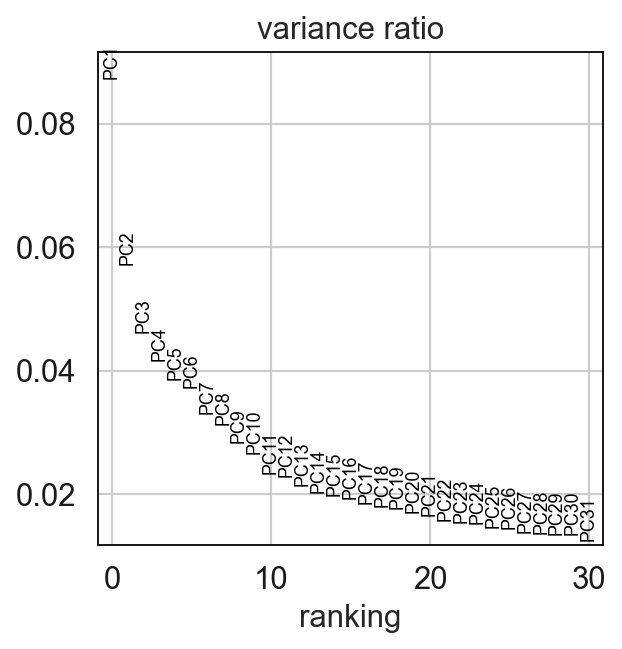

computing neighbors
    using 'X_pca' with n_pcs = 35
    finished (0:01:30)
computing UMAP
    finished (0:08:57)
running Louvain clustering
    using the "louvain" package of Traag (2017)
    finished (0:01:49)


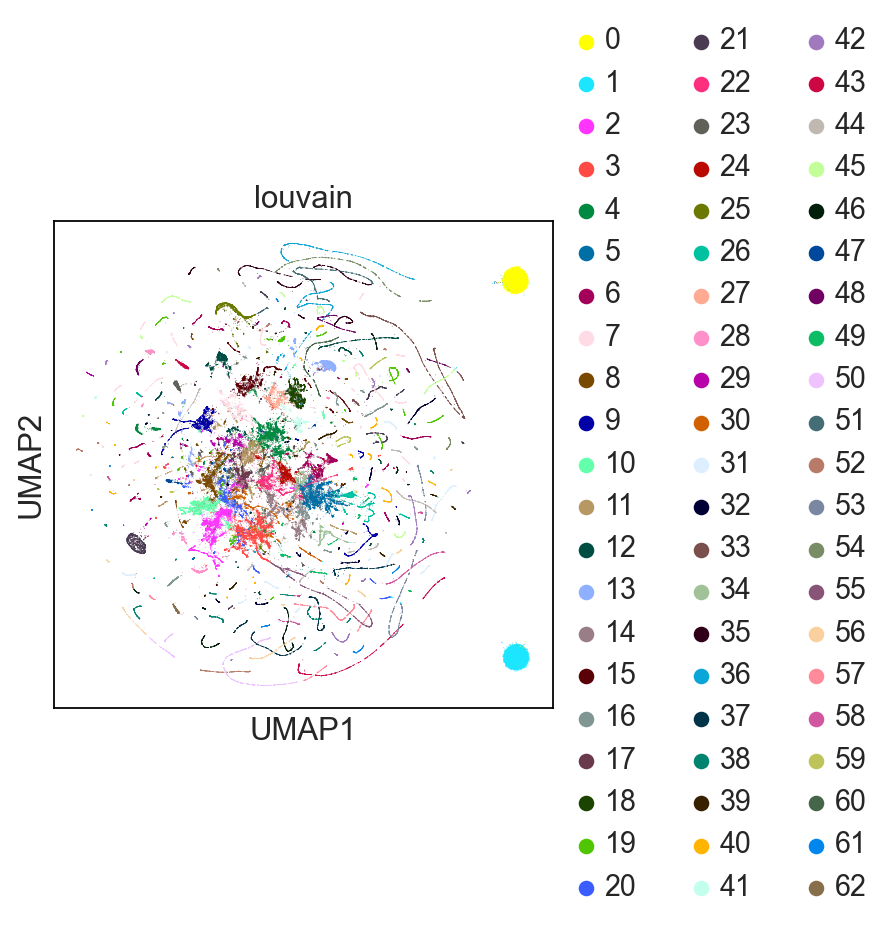

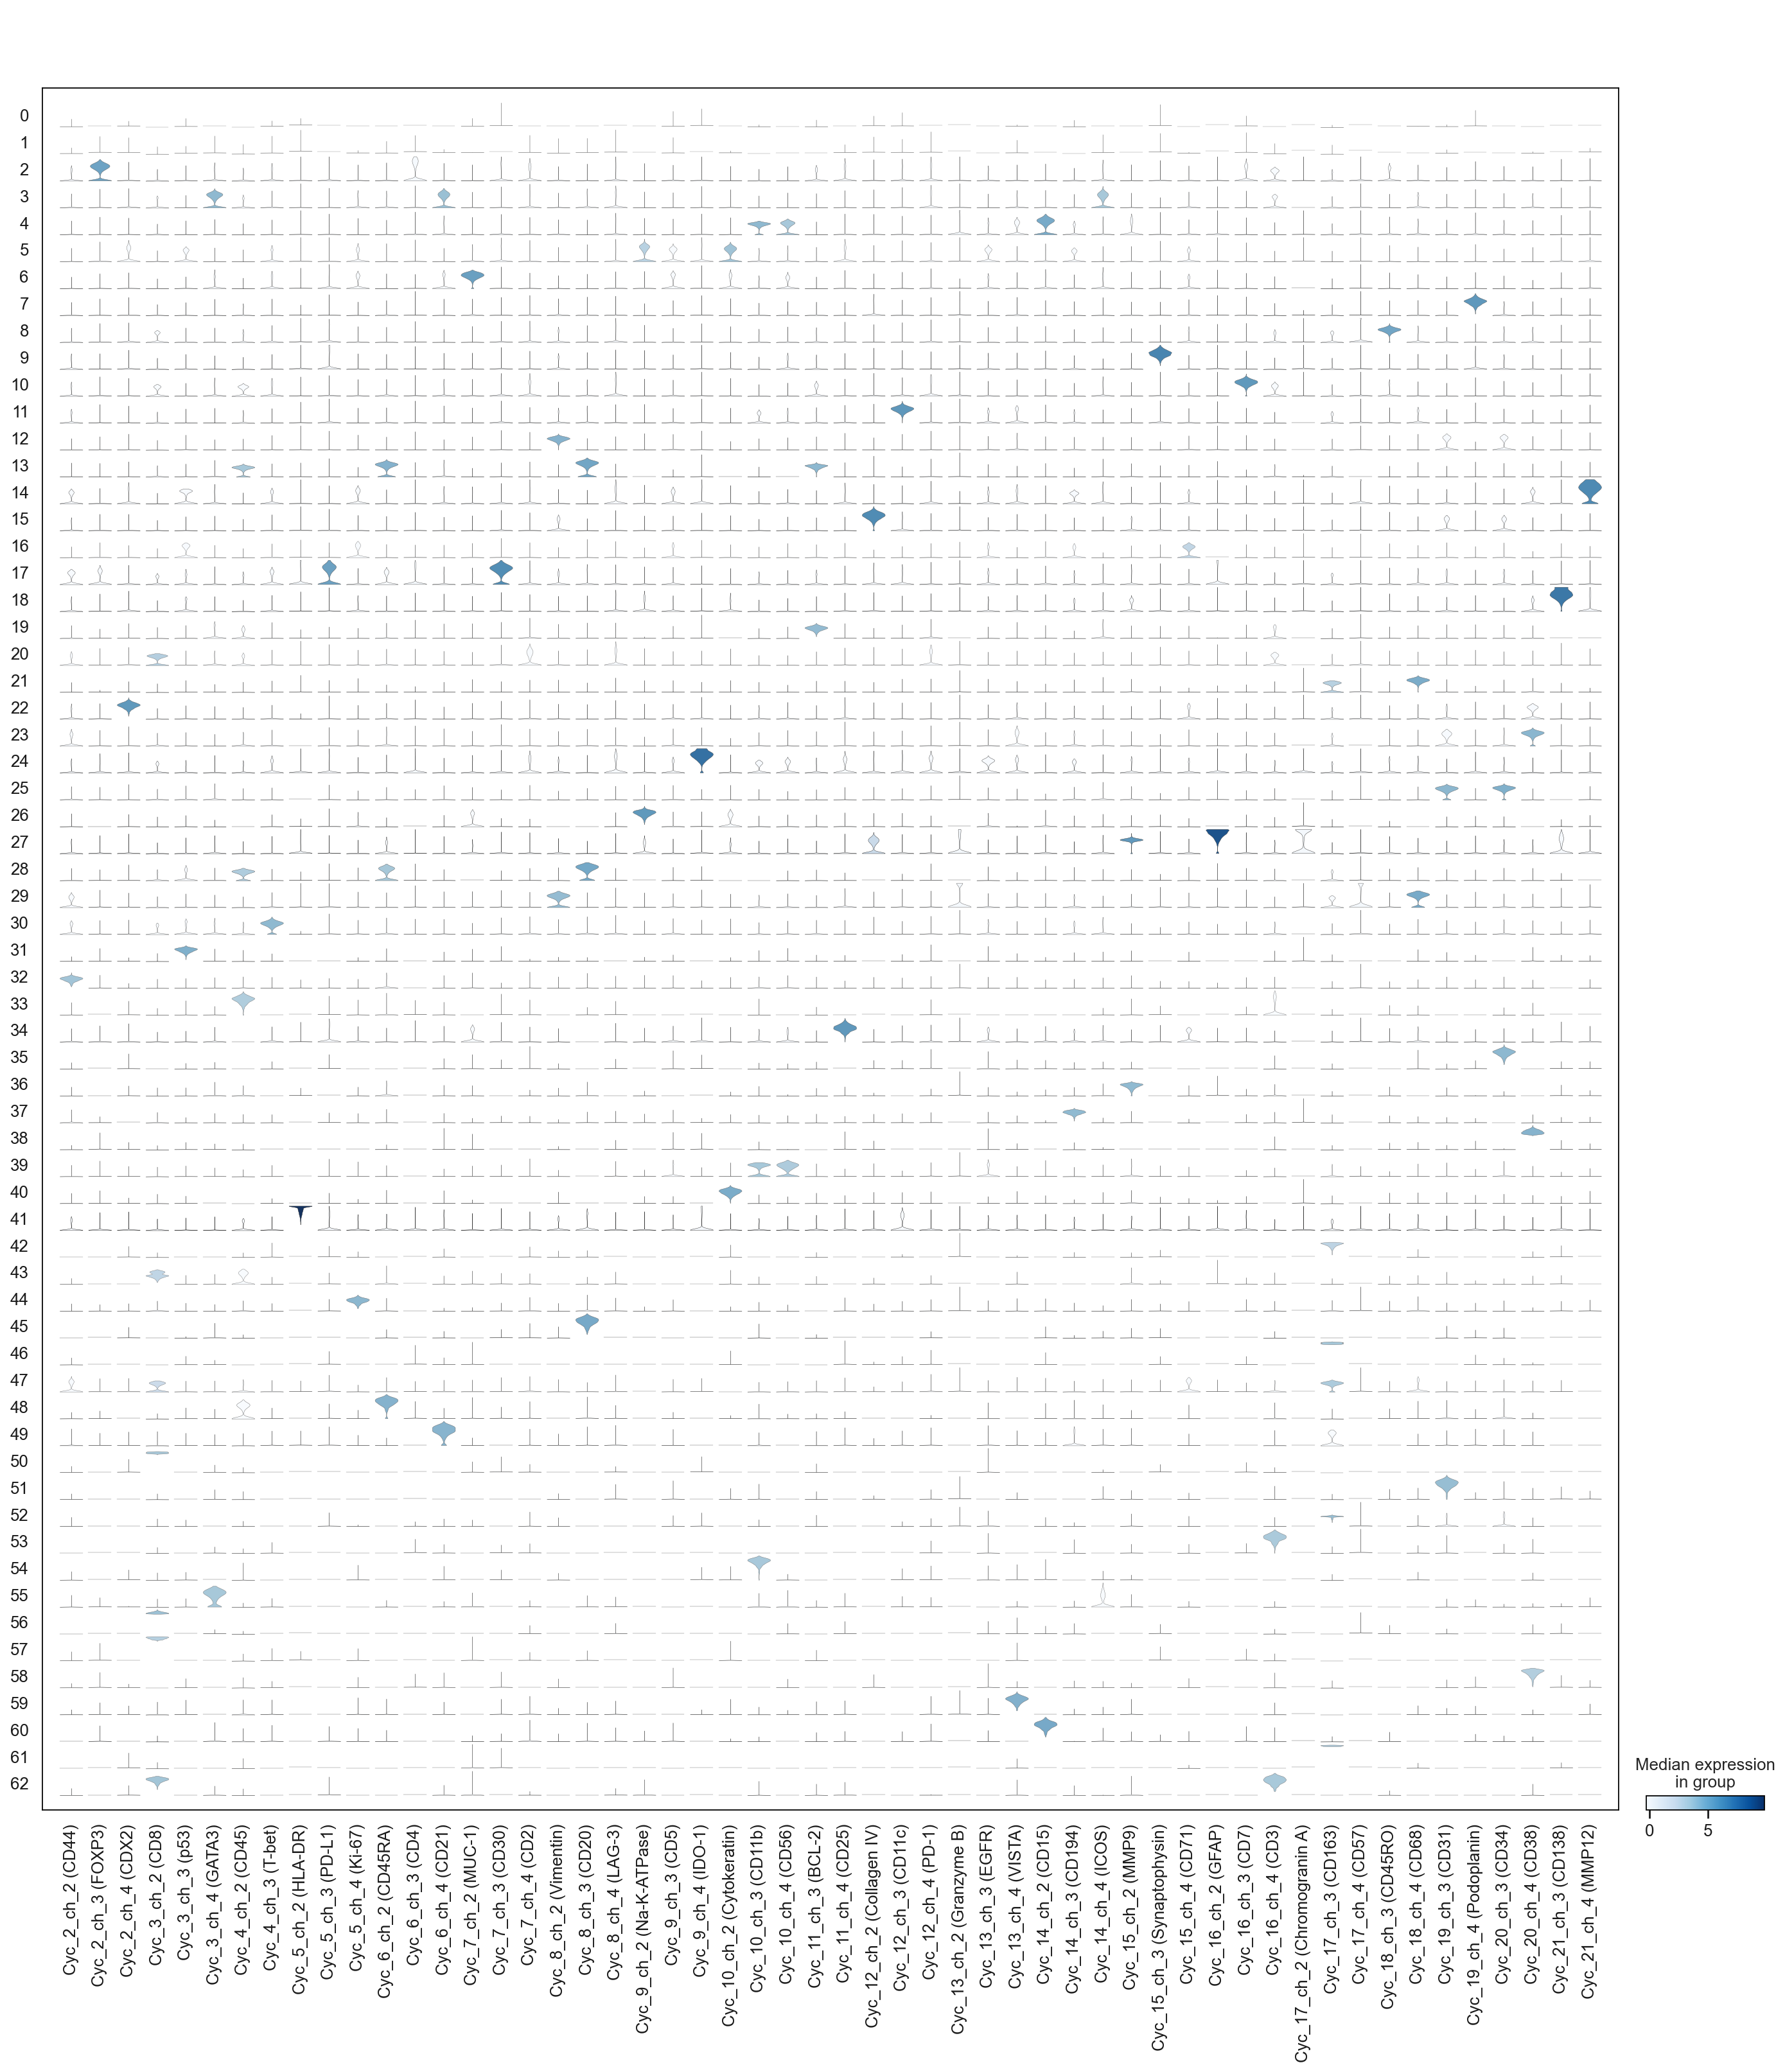

In [15]:
# Confidence threshold for calling a cell "high-confidence" on a given marker.
# Lower = more stringent (fewer, cleaner cells retained for the anchor Louvain clustering).
confidence = 10

highconf = HFcluster.find_highconf_normalized(data_all_scaled, markers, confidence)

umap_params = HFcluster.setParams(min_dist=0.1)

louvain_hf, adata_hc = HFcluster.scluster(
    highconf, markers,
    log=True, metric='euclidean',
    var_maxmean=6, var_mindisp=-2,
    n_neighbors=40, pcs=35, louvain_res=1,
    umap_params=umap_params,
    verbose=2,
)
# louvain_hf -> Louvain cluster label per high-confidence cell
# adata_hc   -> AnnData object with the UMAP embedding etc. for these cells


### 5.3 Propagate labels to all cells

`louvain_hf` only covers the high-confidence subset. `HFcluster.propagateLabels` assigns every
remaining cell (in `data_all_scaled`) to the nearest high-confidence cluster based on its own
(scaled) marker expression, giving a `clusterID` for the **entire** dataset. Cells that were not
part of the high-confidence set are labeled `'0'` in `louvain_hf` before propagation — the printed
percentage below tells you how much of the dataset the Louvain step alone was confident about.


In [16]:
data_all_scaled['louvain_hf'] = louvain_hf
data_all_scaled['umap_1'] = adata_hc.obsm['X_umap'][:, 0]
data_all_scaled['umap_2'] = adata_hc.obsm['X_umap'][:, 1]

pct_labeled = (1 - len(data_all_scaled.loc[data_all_scaled.louvain_hf == '0']) / len(data_all_scaled)) * 100
print(f'{pct_labeled:.2f}% of cells were directly assigned by high-confidence Louvain clustering.')
print('The remainder will receive a label via nearest-neighbor propagation below.')


84.19% of cells were directly assigned by high-confidence Louvain clustering.
The remainder will receive a label via nearest-neighbor propagation below.


In [17]:
output_labels = HFcluster.propagateLabels(data_all_scaled, markers, louvain_hf)
data_all_scaled['clusterID'] = output_labels.values

n_clusters = data_all_scaled['clusterID'].nunique()
print(f'{n_clusters} clusters after propagation.')
print(data_all_scaled['clusterID'].value_counts().sort_index())


62 clusters after propagation.
1     76456
2      6213
3      6052
4      7098
5      6215
      ...  
58      820
59      746
60      677
61      786
62      510
Name: clusterID, Length: 62, dtype: int64


### 5.4 Cluster mean-expression heatmap

`HFcluster.ClusterMeansHeatmap` computes each cluster's mean (z-scored) expression across the
clustering markers and displays it as a clustered heatmap (rows = clusters, columns = markers),
with a dendrogram grouping clusters of similar phenotype. `suggested_cutoff` is a data-driven
suggestion (via `estimate_dist=True`) for how many groups to cut the dendrogram into if you want
to collapse similar clusters into broader lineage categories — see Section 8 for how to use it.


Estimated merge distance is 0.3617367770663039
Suggested number of dendrogram groups: 0.3617367770663039


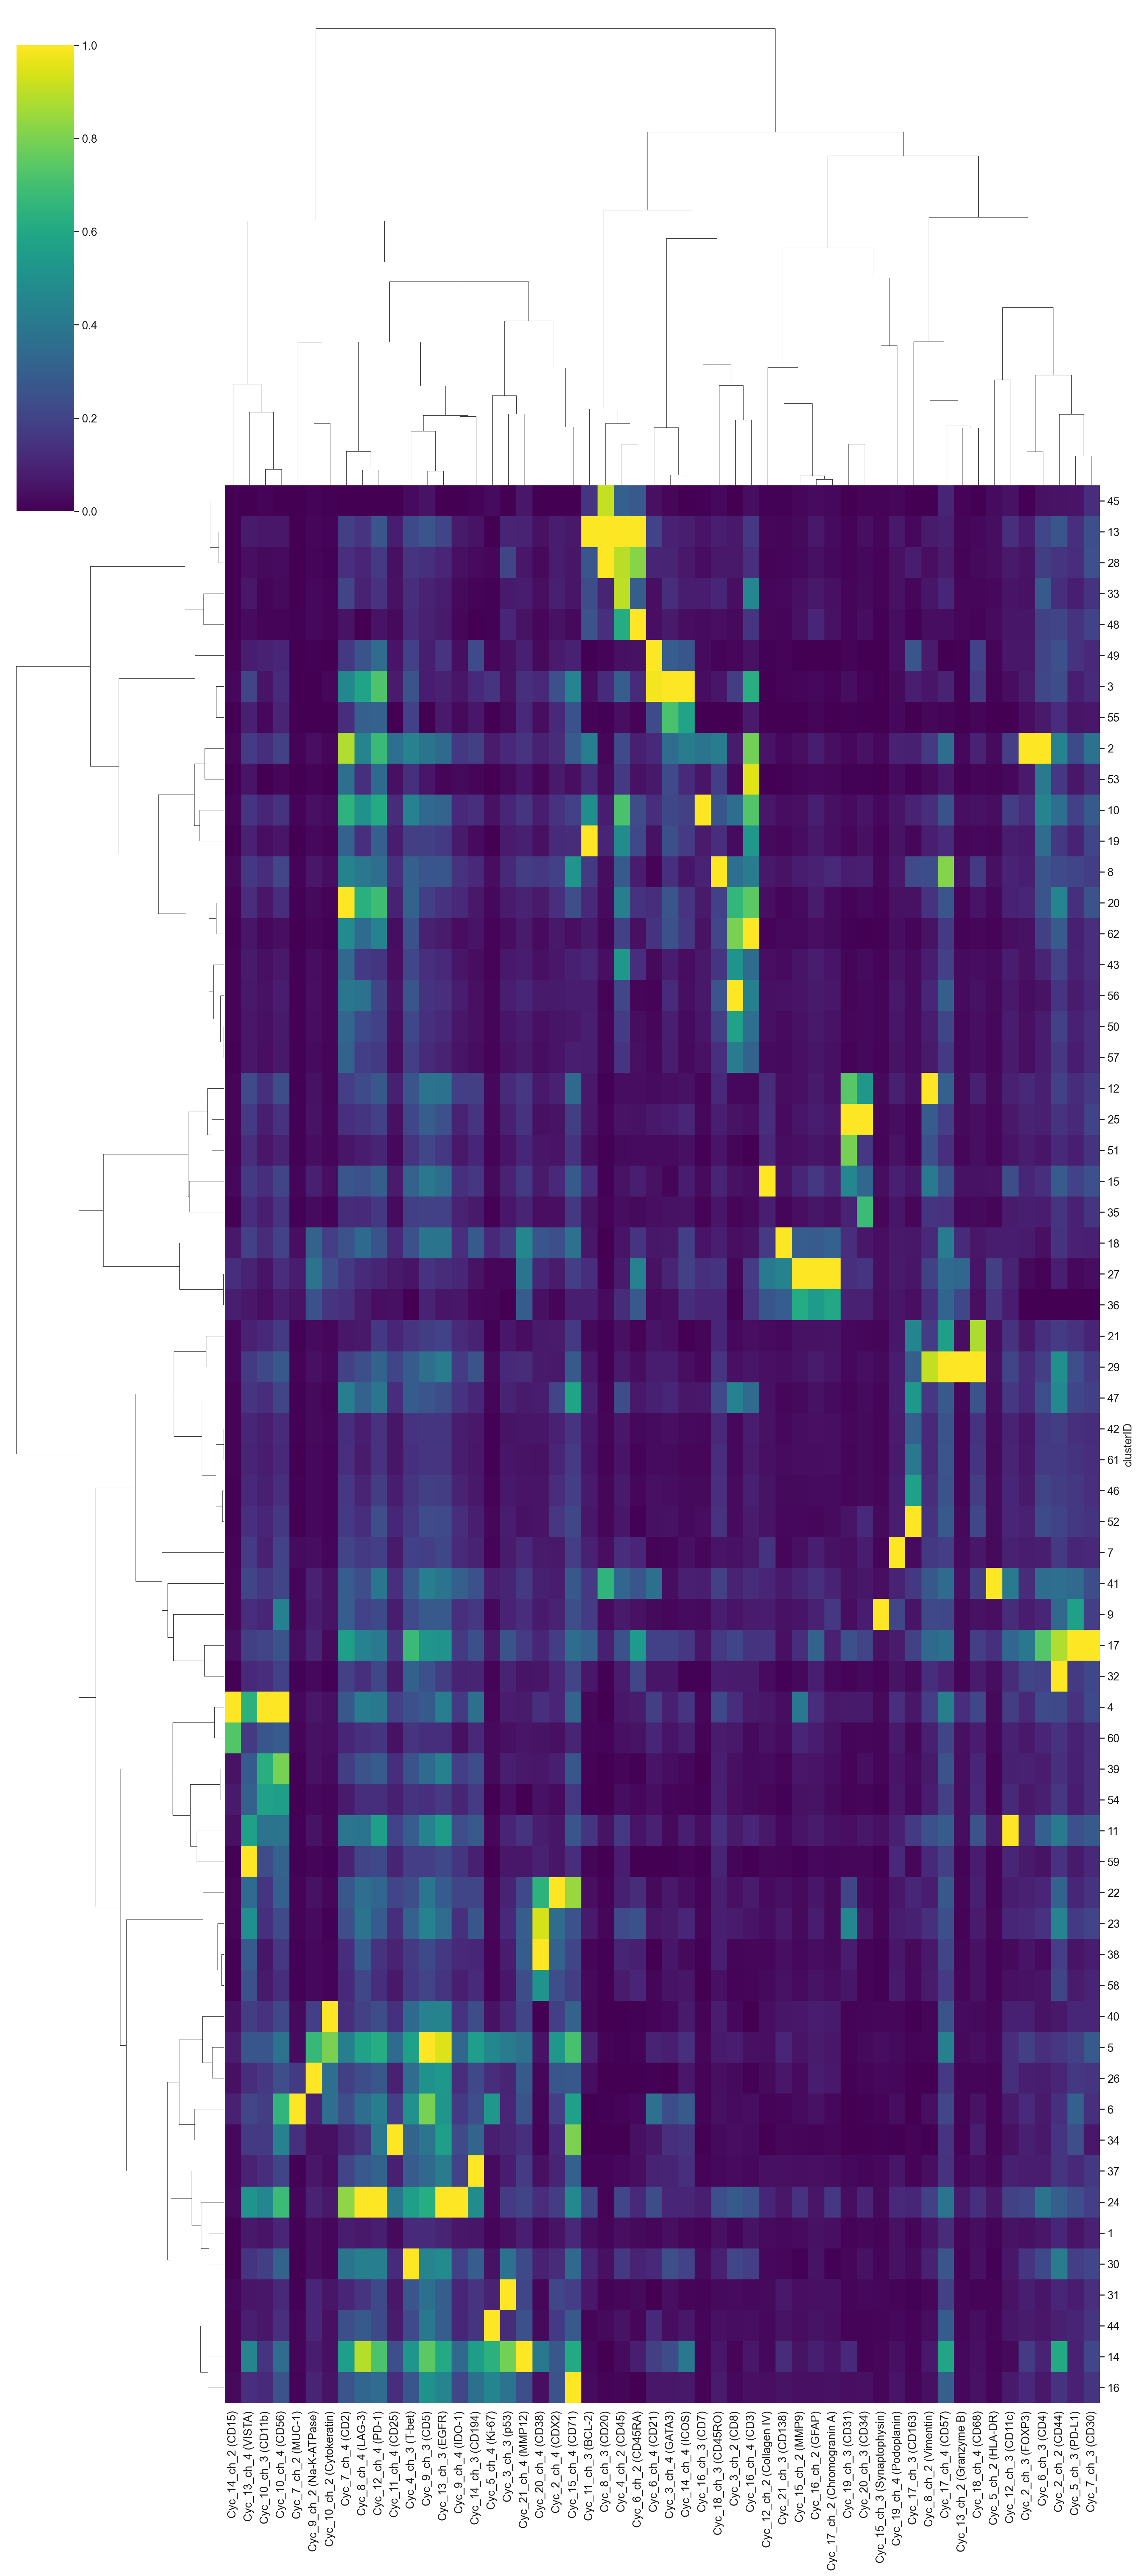

In [18]:
g, suggested_cutoff = HFcluster.ClusterMeansHeatmap(
    data_all_scaled, 'clusterID', markers,
    metric='correlation', method='ward',
    estimate_dist=True,
    save=False, outdir=outdir,
    figsize=(20, 45),
)
print('Suggested number of dendrogram groups:', suggested_cutoff)


## 6. Save annotated results

Uncomment the line below to persist per-cell results (coordinates, all marker intensities, `tissueID`, `condition`,`louvain_hf`, `umap_1/2`, and final `clusterID`) to `outdir`.


In [20]:
# Uncomment to save the fully annotated single-cell table:
data_all_scaled.to_csv(os.path.join(outdir, 'data_all_scaled_clustered.csv'))


## 7. Guide: interpreting the clustering output

This section is reference material, not code to run — read it alongside the heatmap and UMAP you
generated above.

### 7.1 The cluster mean-expression heatmap (Section 5.4)
- Each **row** is one `clusterID`; each **column** is one clustering marker; cell color is the
  cluster's **z-scored mean expression** of that marker (red/warm = high relative to other
  clusters, blue/cool = low), not raw intensity.
- Read across a row to get that cluster's "phenotype fingerprint," e.g. a row bright in `CD3`,
  `CD8`, `Granzyme B` and dim in `Cytokeratin`, `CD20`, `CD68` is consistent with **cytotoxic
  T cells**. A row bright in `Cytokeratin`, `CDX2`, `MUC-1` and dim in immune markers is
  consistent with **tumor/normal colonic epithelium**.
- The **row dendrogram** groups clusters with similar marker profiles — clusters that merge low
  in the tree are close in phenotype (e.g. several T-cell subsets), while clusters that only merge
  near the root are very different lineages (e.g. immune vs. epithelial vs. stromal).
- `suggested_cutoff` gives a statistically motivated place to cut that dendrogram if you want to
  collapse many fine-grained clusters into a handful of broad lineage groups for a summary figure
  — e.g. `scipy.cluster.hierarchy.fcluster(g.dendrogram_row.linkage, t=suggested_cutoff, criterion='maxclust')`
  mapped back onto `clusterID`.
- **A cluster is not automatically "real" just because Louvain produced it.** Always sanity-check:
  does its marker profile make biological sense? Is it a reasonably sized cluster, or a handful of
  outlier cells? Very small clusters with no coherent marker signal are often segmentation
  artifacts or doublets and are reasonable candidates to merge into a neighboring cluster or
  exclude.

### 7.2 Turning clusters into cell-type labels
`clusterID` values are just numbers/strings — they carry no biological meaning until you map them.
A practical workflow:
1. Export the heatmap's underlying cluster-mean table (or read the heatmap directly) and, for each
   cluster, note its top 2-4 discriminating markers.
2. Compare that fingerprint against known marker combinations for the phenotypes expected in CRC
   tissue, e.g.:
   - `Cytokeratin+ CDX2+` → tumor/epithelial cells
   - `CD3+ CD8+` → cytotoxic T cells; `CD3+ CD4+ FOXP3+` → regulatory T cells
   - `CD20+` → B cells; `CD138+` → plasma cells
   - `CD68+ CD163+` → macrophages (CD163 suggests M2-like polarization)
   - `CD31+`/`CD34+` → vascular endothelium; `aSMA+` → smooth muscle/myofibroblasts;
     `Vimentin+ Collagen IV+` (without epithelial markers) → stromal fibroblasts
3. Build a small `dict` mapping `clusterID -> cell_type_label` and add it as a new column, e.g.
   `data_all_scaled['cell_type'] = data_all_scaled['clusterID'].map(cluster_annotations)`.
4. Re-check the heatmap after annotation — clusters you assigned the same label to should look
   visually similar in their marker rows; if not, reconsider whether they should really be merged.

### 7.3 The UMAP embedding (`umap_1`, `umap_2`)
- UMAP is for **visual QC of the clustering**, not for making clustering decisions itself (Louvain
  ran on the graph/PCA space, not on the 2D UMAP coordinates).
- Well-separated, compact islands colored by `clusterID` support that Louvain found coherent
  phenotypes. Clusters that are diffusely intermixed in UMAP space, despite being called separate
  clusters, are worth double-checking against the heatmap — they may be over-split.
- Because only **high-confidence** cells went into the original UMAP/Louvain fit, remember that
  propagated (non-high-confidence) cells inherit a `clusterID` but do **not** have a UMAP
  coordinate calculated from their own expression in the same way — treat `umap_1`/`umap_2` as
  describing the anchor cell population's structure, not literally every cell's individual
  embedding quality.

### 7.4 "% of cells labeled" (Section 5.3)
This reports what fraction of cells were confidently assigned by Louvain *before* propagation. A
low percentage (e.g. well under 50%) usually means:
- `confidence` is too stringent for this panel/tissue (try increasing it), or
- staining quality/signal-to-noise is genuinely low for many markers in this dataset and may be
  worth reviewing at the image level, or
- the marker panel used for clustering (`IncludeMarkers`) includes markers with weak/noisy
  staining that are hurting the "high-confidence" call — consider removing them from clustering
  (they can still be quantified per-cluster afterward).

This is diagnostic, not necessarily a problem — CODEX panels commonly have some low-quality
channels, and propagation is specifically designed to still classify the remaining cells sensibly.

### 7.5 Suggested next steps
- **Per-tissue / per-condition composition:** cross-tabulate `clusterID` (or your annotated
  `cell_type`) against `tissueID` and `condition` (`pd.crosstab`) to compare cell-type proportions
  between the `CLR` and `DII` groups.
- **Spatial context:** once clusters are biologically annotated, `CellNeighborhood.py` (imported in
  Section 1) can group cells into recurrent spatial neighborhoods based on the local mixture of
  cell types around each cell — useful for identifying tumor-immune interfaces, tertiary lymphoid
  structures, etc.
- **Stability check:** re-run Section 5 with a different `confidence` value or `louvain_res` and
  confirm the major phenotypes (and their proportions) are stable — this is a reasonable
  robustness check before reporting cluster-based findings.
